#📌 Extracción

In [2]:
import pandas as pd

In [3]:
datos = pd.read_json("TelecomX_Data.json")

In [4]:
datos

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [5]:
df_customer = pd.json_normalize(datos["customer"])

In [6]:
df_customer

,gender,SeniorCitizen,Partner,Dependents,tenure
0,Female,0,Yes,Yes,9
1,Male,0,No,No,9
2,Male,0,No,No,4
3,Male,1,Yes,No,13
4,Female,1,Yes,No,3
...,...,...,...,...,...
7262,Female,0,No,No,13
7263,Male,0,Yes,No,22
7264,Male,0,No,No,2
7265,Male,0,Yes,Yes,67


In [7]:
df_phone = pd.json_normalize(datos["phone"])

In [8]:
df_internet = pd.json_normalize(datos["internet"])

In [9]:
df_account = pd.json_normalize(datos["account"])

In [10]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [11]:
datos.dtypes

customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object

#🔧 Transformación

In [12]:
df_base = pd.DataFrame(datos)[['customerID', 'Churn']]

In [13]:
df_final = pd.concat([df_base, df_customer, df_phone, df_internet, df_account], axis=1)

In [14]:
print(df_final.head())

   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female              0     Yes        Yes       9   
1  0003-MKNFE    No    Male              0      No         No       9   
2  0004-TLHLJ   Yes    Male              0      No         No       4   
3  0011-IGKFF   Yes    Male              1     Yes         No      13   
4  0013-EXCHZ   Yes  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Yes         Yes              No        One year   
1       

In [15]:
print(df_final.columns)

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')


In [16]:
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

In [17]:
print(f"Valores nulos en Total: {df_final['Charges.Total'].isnull().sum()}")

Valores nulos en Total: 11


In [18]:
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

In [19]:
print(f"Nulos restantes: {df_final['Charges.Total'].isnull().sum()}")

Nulos restantes: 0


In [20]:
print(df_final['Churn'].unique())

['No' 'Yes' '']


In [21]:
df_final['Churn'] = df_final['Churn'].map({'Yes': 1, 'No': 0})

In [22]:
print(df_final['gender'].unique())

['Female' 'Male']


In [23]:
df_final['gender'] = df_final['gender'].map({'Female': 1, 'Male': 0})

In [24]:
df_final['Cuentas_Diarias'] = df_final['Charges.Monthly'] / 30

In [25]:
print(df_final[['Charges.Monthly', 'Cuentas_Diarias']].head())

   Charges.Monthly  Cuentas_Diarias
0             65.6         2.186667
1             59.9         1.996667
2             73.9         2.463333
3             98.0         3.266667
4             83.9         2.796667


In [26]:
df_final['Cuentas_Diarias'] = df_final['Cuentas_Diarias'].round(2)

#📊 Carga y análisis

In [27]:
columnas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

In [28]:
analisis_stats = df_final[columnas_numericas].describe()

In [29]:
print("--- Análisis Estadístico Descriptivo ---")
print(analisis_stats)

--- Análisis Estadístico Descriptivo ---
            tenure  Charges.Monthly  Charges.Total  Cuentas_Diarias
count  7267.000000      7267.000000    7267.000000      7267.000000
mean     32.346498        64.720098    2277.182035         2.157292
std      24.571773        30.129572    2268.648587         1.004407
min       0.000000        18.250000       0.000000         0.610000
25%       9.000000        35.425000     396.200000         1.180000
50%      29.000000        70.300000    1389.200000         2.340000
75%      55.000000        89.875000    3778.525000         2.995000
max      72.000000       118.750000    8684.800000         3.960000


In [30]:
import matplotlib.pyplot as plt

In [31]:
churn_data = df_final['Churn'].value_counts()
labels = churn_data.index
values = churn_data.values

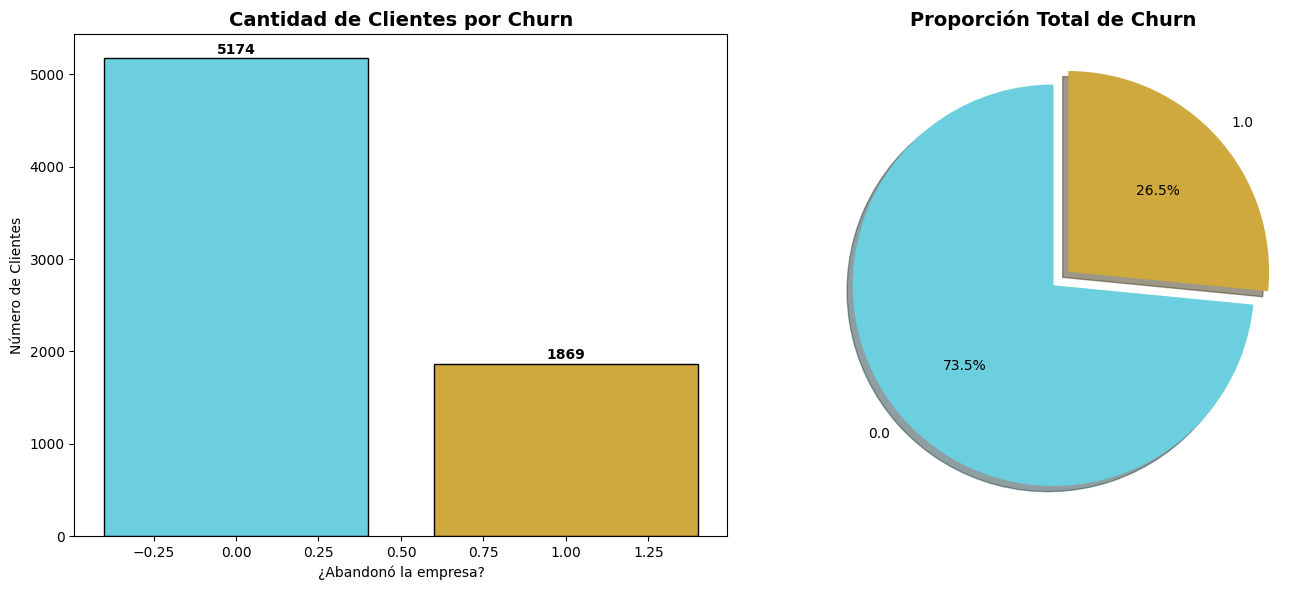

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colores = ["#6BCFE0", "#CFA93E"]
ax1.bar(labels, values, color=colores, edgecolor='black')
ax1.set_title('Cantidad de Clientes por Churn', fontsize=14, fontweight='bold')
ax1.set_xlabel('¿Abandonó la empresa?')
ax1.set_ylabel('Número de Clientes')

for i, v in enumerate(values):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

ax2.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=colores, explode=(0, 0.1), shadow=True)
ax2.set_title('Proporción Total de Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

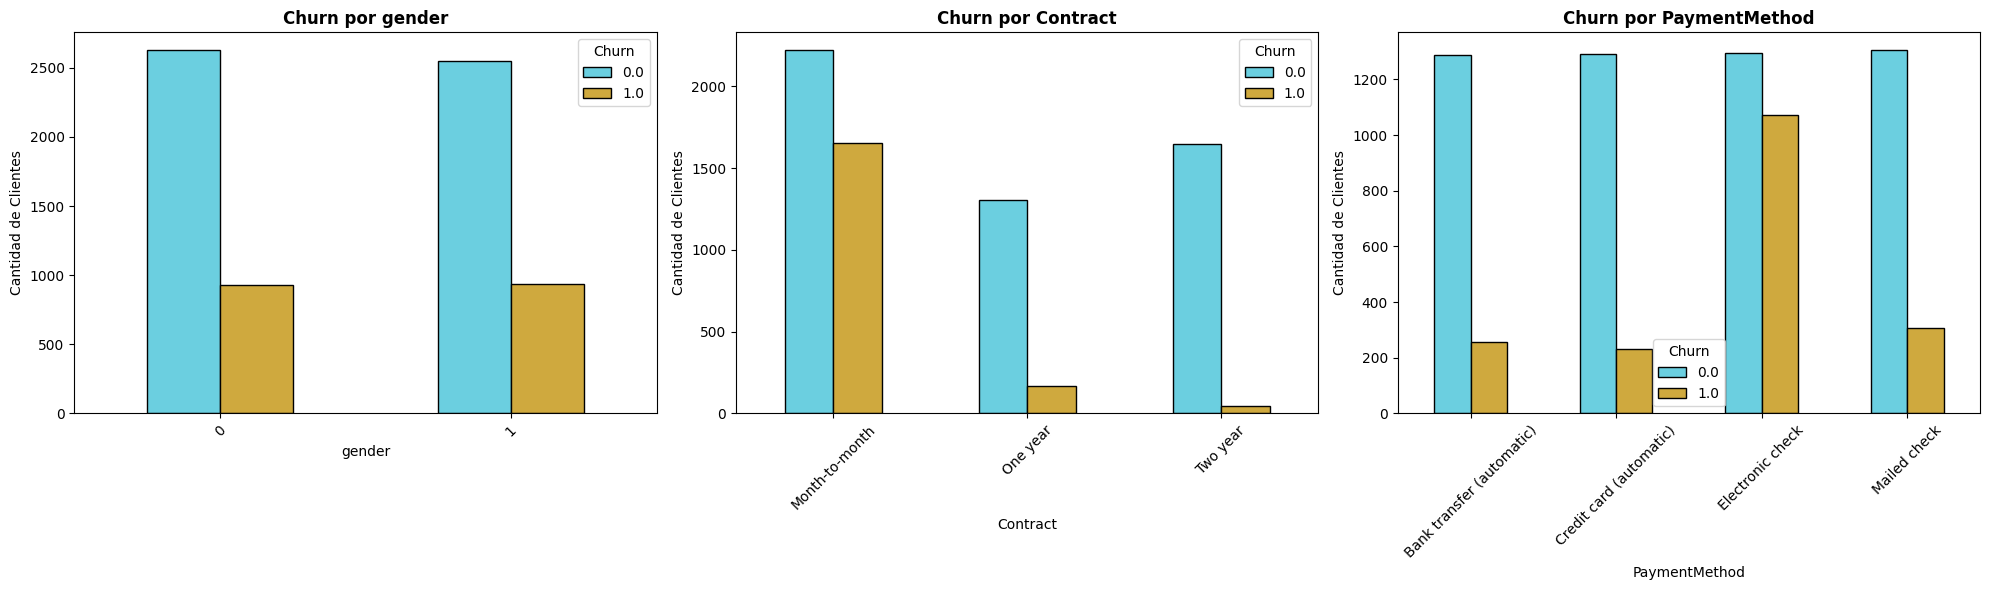

In [38]:
import matplotlib.pyplot as plt

variables = ['gender', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(variables):
    cross_tab = pd.crosstab(df_final[col], df_final['Churn'])
    
    cross_tab.plot(kind='bar', ax=axes[i], color=["#6BCFE0", "#CFA93E"], edgecolor='black')
    
    axes[i].set_title(f'Churn por {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad de Clientes')
    axes[i].legend(title='Churn')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [34]:
import plotly.express as px

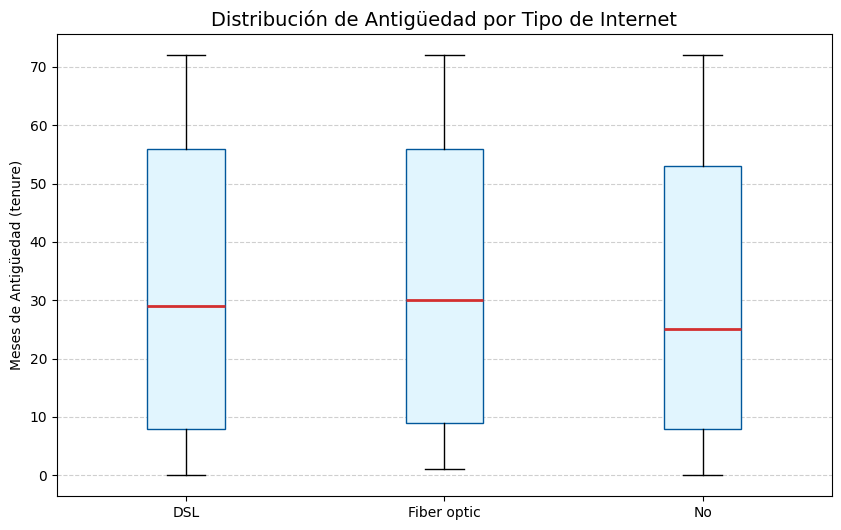

In [37]:
import matplotlib.pyplot as plt
import plotly.express as px


tipos_internet = df_final['InternetService'].unique()
datos_boxplot = [df_final[df_final['InternetService'] == s]['tenure'] for s in tipos_internet]

plt.figure(figsize=(10, 6))
plt.boxplot(datos_boxplot, tick_labels=tipos_internet, patch_artist=True,
            boxprops=dict(facecolor='#E1F5FE', color='#01579B'),
            medianprops=dict(color='#D32F2F', linewidth=2))

plt.title('Distribución de Antigüedad por Tipo de Internet', fontsize=14)
plt.ylabel('Meses de Antigüedad (tenure)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

fig = px.scatter(df_final,
                 x="Charges.Monthly",
                 y="Charges.Total",
                 color="Contract",
                 hover_data=['customerID', 'tenure'],
                 title="Relación Gasto Mensual vs. Total por Tipo de Contrato",
                 labels={'Charges.Monthly': 'Cargo Mensual ($)', 'Charges.Total': 'Cargo Total ($)'},
                 template="plotly_white")

fig.show()

#📄Informe final

 # **Informe de Cierre: Estrategia de Retención Telecom X**
 
 ## **Objetivo del Proyecto**
 *Este análisis busca transformar datos crudos de telecomunicaciones en decisiones estratégicas. El problema central es el Churn (evasión), que actualmente afecta al 26.5% de nuestra cartera de clientes. El éxito del proyecto se basa en entender quién se va y por qué lo hace.*

 ## **Resumen del Pipeline de Datos**
 Para garantizar la calidad de los hallazgos, se realizó un proceso técnico riguroso:Consolidación: Unión de 5 fuentes de datos anidadas (JSON) en un DataFrame maestro de 7,267 registros.Saneamiento: Imputación de valores en Charges.Total y corrección de tipos de datos.Enriquecimiento: Creación de la métrica Cuentas_Diarias para analizar el micro-consumo.*

## **Hallazgos de Alto Impacto (Insights)**
*A partir del análisis de datos, se han identificado cuatro pilares fundamentales que explican la evasión de clientes:*

- *Tipo de Contrato: Se observó que los contratos definidos como "Mes a mes" presentan la mayor tasa de fuga de toda la cartera. Debido a la falta de compromiso a largo plazo, este factor se clasifica como un riesgo crítico para la estabilidad de los ingresos.*

- *Antigüedad del Cliente: El análisis histórico revela que el abandono no es aleatorio; ocurre mayoritariamente durante los primeros 6 meses de servicio. Esto indica un riesgo alto de fuga temprana, sugiriendo que la experiencia inicial del usuario es determinante.*

- *Tecnología de Conexión: Existe un comportamiento paradójico en los clientes de Fibra Óptica. Aunque son los que generan mayores ingresos por sus cuotas elevadas, también muestran una rotación más alta que otros servicios. Esto representa un riesgo medio, posiblemente ligado a una percepción de baja relación entre precio y calidad o problemas de estabilidad técnica.*

- *Comportamiento de Gastos: Se confirmó una correlación directa entre el costo del servicio y la evasión. A medida que aumenta el cargo mensual, crece proporcionalmente la probabilidad de Churn. Este hallazgo subraya un riesgo alto por sensibilidad al precio, donde los clientes de alto valor son, a su vez, los más volátiles si no perciben un valor diferencial.*
 
 ## **Conclusiones Visuales**
 **Estabilidad Financiera:** *Gracias al gráfico de Plotly, confirmamos que los clientes con contratos de 1 y 2 años no solo son más leales, sino que generan un LTV (Lifetime Value) hasta 5 veces superior al cliente promedio.*
 
 **Perfil de Evasión:** *El "cliente en riesgo" típico es aquel con servicio de Fibra Óptica, pago por cheque electrónico y contrato sin permanencia.*
 
 ## **Recomendaciones de Negocio**
 1. **Plan de Lealtad "Primer Año":** *Implementar un sistema de recompensas escalonado durante los primeros 12 meses para cruzar la "barrera crítica" de antigüedad.
 
 2. **Migración Asistida:** *Lanzar una campaña de telemarketing dirigida exclusivamente a usuarios "Mes a mes" ofreciendo un descuento del 15% si migran a un contrato anual.*
 
 3. **Auditoría de Fibra Óptica:** *Investigar si la alta rotación en fibra se debe a problemas de estabilidad técnica o si el precio es poco competitivo frente al mercado.*
 
 4. **Automatización de Pagos:** *Incentivar el uso de pagos automáticos (Credit Card/Bank Transfer) mediante un pequeño bono mensual, ya que estos métodos presentan la menor tasa de evasión.*